<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/notebooks/parameter_sweep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parameter sweep: repulsion strength, per-gene cap, and the β prior

This notebook measures how sensitive CellSweep is to its regularization settings:

* **ρ** (`repulsion_strength`): how strongly cell-type profiles are pushed away from the ambient
  profile. Repulsion stays on through both training stages.
* **cap** (`max_frac_gene_repulsion`): the largest fraction of a gene's expected count that one
  repulsion step may remove. ρ and the cap interact: together they set how hard repulsion pushes,
  especially on genes that are abundant in the ambient profile.
* **κ** (`beta_prior_strength`): the weight of the Beta prior on the global contamination fraction β,
  as a fraction of the total counts (prior mode `beta_prior_mode = 0.01`).

The sweeps are centered on the model's defaults (ρ = 1e-3, κ = 1e-2, cap = 0.25; `init_beta = 0.01`):

1. **ρ × cap grid** (ρ ∈ {1e-5, 1e-4, 3e-4, 1e-3, 3e-3}, cap ∈ {0.1, 0.2, 0.25, 0.3, 0.4}) at the
   default stopping rule. ρ = 3e-3 lies above the default so that the default is not at the edge of the grid.
2. **κ sweep** at the default ρ and cap, default stopping.
3. **Convergence check**: every cap at the default ρ, run both with the default stopping rule and to
   convergence (3,000 iterations, tight tolerances). A setting is only useful if both runs agree.
   Convergence runs take most of the compute, so they are limited to this column.

Results are scored against the ground truth each dataset offers:

| dataset | ground truth | noise removed | signal kept |
|---|---|---|---|
| `hgmm_12k` | species of each read (human–mouse mixture) | cross-species counts | same-species counts |
| `pbmc8k` | canonical immune markers | off-target marker counts | on-target marker counts; DC contamination as an over-correction flag |
| `kidney_nuclei_10k` | proximal tubule (PT) markers | PT markers in non-PT cells | PT markers in PT cells |
| `janssen_nuc2/3` | genotype (Janssen et al. 2023, *Genome Biol.* 24:140) | Kendall τ / RMSLE vs per-nucleus background; PT markers in non-PT nuclei | PT markers in PT nuclei |

The notebook is self-contained: any input it can't find is downloaded and prepared, and anything
already on disk at the locations the other notebooks use is reused. The Janssen metadata is stored
in Seurat `.RDS` files and needs `Rscript` on `PATH` (base R only). Remove the two Janssen entries
from `datasets` if R isn't available.

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import contextlib
import io
import os
import re
import subprocess
import time
import urllib.request
import zipfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.stats import kendalltau

import cellsweep.utils as cs_utils
from cellsweep import denoise_count_matrix

cellsweep_dir = os.path.dirname(os.path.abspath(""))

In [3]:
datasets = ["hgmm_12k", "pbmc8k", "kidney_nuclei_10k", "janssen_nuc2", "janssen_nuc3"]

default = dict(rho=1e-3, kappa=1e-2, cap=0.25)  # the model's defaults: the reference setting in every plot

# 1. rho x cap grid, default stopping
rho_grid = [1e-5, 1e-4, 3e-4, 1e-3, 3e-3]
cap_grid = [0.1, 0.2, 0.25, 0.3, 0.4]
# 2. beta prior strength at the default rho and cap, default stopping
kappa_grid = [0, 1e-3, 1e-2, 3e-2]
# 3. convergence check: every cap at the default rho, both stopping modes
long_cap = cap_grid

# Janssen inputs: split the authors' PT label by their Seurat clusters at this resolution (None keeps the
# authors' coarse labels); PT clusters with fewer than janssen_min_cluster nuclei are pooled into PT_other
janssen_label_resolution = 0.5
janssen_min_cluster = 50

modes = {
    "default": {},                                          # the model's own stopping rule
    "long": dict(tol_p=1e-8, tol_f=1e-8, max_iter=3000),    # run to convergence
}

threads = 16
overwrite = False   # rebuild inputs and rerun settings that already exist
quick = False       # True: only the default setting at default stopping (a fast end-to-end check)

data_root = os.path.join(cellsweep_dir, "notebooks", "data")
sweep_data_dir = os.path.join(data_root, "parameter_sweep")
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", "parameter_sweep")
log_dir = os.path.join(out_dir, "logs")
results_csv = os.path.join(out_dir, "results.csv")
for d in (sweep_data_dir, out_dir, log_dir):
    os.makedirs(d, exist_ok=True)

## Prepare inputs

Each dataset is prepared once and cached. Every step first checks the location the other notebooks
use (`benchmarking.ipynb` for the 10x datasets, `janssen_snrna.ipynb` for Janssen) and reuses
anything it finds.

**10x datasets** are prepared the way `benchmarking.ipynb` prepares them, using each dataset's config
in `notebooks/config/`:
1. Call barcodes below the knee-plot cutoff at `expected_cells` non-cellular.
2. Label cell types. hgmm_12k uses species plus human–mouse doublet calls; the others use CellTypist.

In [4]:
def download(url, path):
    if os.path.exists(path):
        return "reused"
    os.makedirs(os.path.dirname(path), exist_ok=True)
    print(f"  downloading {url}")
    urllib.request.urlretrieve(url, path + ".part")
    os.replace(path + ".part", path)
    return "downloaded"


def prepare_10x(ds):
    """Raw 10x matrix with is_empty and celltype (and is_doublet for hgmm), as in benchmarking.ipynb."""
    out = os.path.join(sweep_data_dir, f"{ds}_input.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"{ds}: reused {out}")
        return out
    cfg = cs_utils.load_dataset_yaml(os.path.join(cellsweep_dir, "notebooks", "config", f"{ds}.yaml"))
    raw_path = os.path.join(data_root, ds, os.path.basename(cfg["adata_raw_url"]))
    print(f"{ds}: raw matrix {download(cfg['adata_raw_url'], raw_path)} ({raw_path})")

    adata = cs_utils.load_adata(raw_path)
    adata.var_names_make_unique()
    expected_cells = cfg["expected_cells"]
    umi_cutoff = cs_utils.knee_plot(adata, expected_cells=expected_cells, show=False)
    adata = cs_utils.infer_empty_droplets(adata, method="threshold", umi_cutoff=umi_cutoff)

    if ds == "hgmm_12k":
        is_h = (adata.var["genome"] == "hg19").values
        h = np.asarray(adata.X[:, is_h].sum(axis=1)).ravel()
        m = np.asarray(adata.X[:, ~is_h].sum(axis=1)).ravel()
        adata.obs["celltype"] = np.where(h >= m, "hg19", "mm10")
        sc.pp.filter_cells(adata, min_counts=1)
        adata = cs_utils.detect_doublets_human_mouse(adata, fraction_doublet=cfg["fraction_doublet"], plot_empty=False,
                                                     umi_cutoff=umi_cutoff, expected_cells=expected_cells, show=False)
    else:
        adata = cs_utils.determine_cell_types(adata, model_pkl=cfg["model_pkl"], filter_empty=True,
                                              expected_cells=expected_cells, celltypist_convert=cfg["celltypist_convert"],
                                              celltypist_map_file=cfg["celltypist_map_file"])

    adata.uns["umi_cutoff"] = float(umi_cutoff)
    adata.write_h5ad(out)
    print(f"{ds}: built {out}")
    return out

**Janssen et al. (2023)** pooled kidneys from three mouse strains before droplet capture. Reads that
carry a foreign allele are background, which gives a per-nucleus background estimate (`bRNA`) for
the CAST nuclei. The inputs are built the same way `janssen_snrna.ipynb` builds them:
* the authors' called nuclei and cell types,
* every other barcode with 0 < UMI < 100 treated as non-cellular,
* the rest dropped.

The authors' proximal-tubule (PT) label covers most nuclei and several distinct PT populations. With
that coarse label, CellSweep's burn-in moves hundreds of poorly fit PT nuclei into a nearly empty
cell type (and warns about it), and those nuclei get poorly determined contamination estimates. As
label-based methods are best given labels at the resolution of the data, the sweep splits PT by the
authors' own Seurat clusters (`janssen_label_resolution`; `None` restores the coarse labels). Scores
are always computed with the authors' labels, so "PT" still means every PT nucleus.

In [5]:
JANSSEN_DIR = os.path.join(data_root, "janssen2023")
JANSSEN_ZENODO = "https://zenodo.org/records/7328632/files"
JANSSEN_EMPTY_UMI = 100
PT_MARKERS = ["Slc34a1", "Miox", "Pck1", "Slc4a4", "Ttc36", "Lrp2", "Fbp1", "Cyp2e1", "Fut9", "Khk"]
CONSTITUTIVE = ["Malat1", "Fth1", "Ftl1", "Tpt1", "Psap", "App"]

R_EXPORT = r"""
suppressWarnings({
  for (d in commandArgs(TRUE)) {
    md <- as.data.frame(attr(readRDS(file.path(d, "seurat.RDS")), "meta.data"))
    md$cell <- rownames(md)
    write.csv(md, file.path(d, "seurat_metadata.csv"), row.names = FALSE)
  }
})
"""


def prepare_janssen(rep):
    rep_dir = os.path.join(JANSSEN_DIR, rep)
    out = os.path.join(rep_dir, f"adata_raw_empty{JANSSEN_EMPTY_UMI}.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"janssen_{rep}: reused {out}")
        return out

    if not os.path.isdir(rep_dir):
        zip_path = os.path.join(JANSSEN_DIR, f"{rep}.zip")
        download(f"{JANSSEN_ZENODO}/{rep}.zip?download=1", zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(JANSSEN_DIR)

    md_path = os.path.join(rep_dir, "seurat_metadata.csv")
    if not os.path.exists(md_path):
        script = os.path.join(JANSSEN_DIR, "export_metadata.R")
        with open(script, "w") as f:
            f.write(R_EXPORT)
        subprocess.run(["Rscript", script, rep_dir], check=True)
    md_df = pd.read_csv(md_path).set_index("cell")

    adata = cs_utils.load_adata(os.path.join(rep_dir, "raw_feature_bc_matrix.h5"))
    adata.var_names_make_unique()
    total = np.asarray(adata.X.sum(axis=1)).ravel()
    is_cell = np.asarray(adata.obs_names.isin(md_df.index))
    keep = is_cell | ((total > 0) & (total < JANSSEN_EMPTY_UMI))
    adata = adata[keep].copy()
    adata.obs["is_empty"] = ~np.asarray(adata.obs_names.isin(md_df.index))
    adata.obs["celltype"] = md_df["celltype"].reindex(adata.obs_names).fillna("empty").values
    for col in ["Strain", "bRNA", "nSNP"]:
        adata.obs[col] = md_df[col].reindex(adata.obs_names).values
    adata.uns["umi_cutoff"] = float(JANSSEN_EMPTY_UMI)
    adata.write_h5ad(out)
    print(f"janssen_{rep}: built {out} ({int(is_cell.sum()):,} nuclei, {int(adata.obs['is_empty'].sum()):,} non-cellular)")
    return out


def janssen_sweep_input(rep):
    # the prepared matrix with the authors' PT label split by their Seurat clusters (see config)
    base = prepare_janssen(rep)
    if janssen_label_resolution is None:
        return base
    out = os.path.join(sweep_data_dir, f"janssen_{rep}_input_res{janssen_label_resolution:g}_min{janssen_min_cluster}.h5ad")
    if os.path.exists(out) and not overwrite:
        print(f"janssen_{rep}: reused {out}")
        return out
    adata = ad.read_h5ad(base)
    md_df = pd.read_csv(os.path.join(JANSSEN_DIR, rep, "seurat_metadata.csv")).set_index("cell")
    author = adata.obs["celltype"].astype(str).values
    clusters = md_df[f"RNA_snn_res.{janssen_label_resolution:g}"].reindex(adata.obs_names)
    is_pt = author == "PT"
    sizes = clusters[is_pt].value_counts()
    keep = set(sizes[sizes >= janssen_min_cluster].index)
    label = author.copy()
    label[is_pt] = [f"PT_c{int(c)}" if c in keep else "PT_other" for c in clusters[is_pt]]
    adata.obs["celltype_author"] = author
    adata.obs["celltype"] = label
    adata.write_h5ad(out)
    print(f"janssen_{rep}: built {out} (PT split into {len(set(label[is_pt]))} labels)")
    return out

In [6]:
input_paths = {}
for ds in datasets:
    input_paths[ds] = janssen_sweep_input(ds.split("_")[1]) if ds.startswith("janssen_") else prepare_10x(ds)

for ds, path in input_paths.items():
    obs = ad.read_h5ad(path, backed="r").obs
    cells = ~obs["is_empty"].astype(bool)
    print(f"{ds:18s} {int(cells.sum()):7,} cells  {int((~cells).sum()):9,} non-cellular  "
          f"cell types: {obs.loc[cells, 'celltype'].nunique()}")

hgmm_12k: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/hgmm_12k_input.h5ad
pbmc8k: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/pbmc8k_input.h5ad
kidney_nuclei_10k: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/kidney_nuclei_10k_input.h5ad
janssen_nuc2: reused /home/mcaskey/cellsweep/notebooks/data/janssen2023/nuc2/adata_raw_empty100.h5ad
janssen_nuc2: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/janssen_nuc2_input_res0.5_min50.h5ad
janssen_nuc3: reused /home/mcaskey/cellsweep/notebooks/data/janssen2023/nuc3/adata_raw_empty100.h5ad
janssen_nuc3: reused /home/mcaskey/cellsweep/notebooks/data/parameter_sweep/janssen_nuc3_input_res0.5_min50.h5ad


hgmm_12k            12,820 cells    664,623 non-cellular  cell types: 2


pbmc8k               8,381 cells    728,899 non-cellular  cell types: 7


kidney_nuclei_10k   10,321 cells    547,669 non-cellular  cell types: 5


janssen_nuc2        16,714 cells  1,462,006 non-cellular  cell types: 26


janssen_nuc3         4,266 cells  1,461,582 non-cellular  cell types: 21


## Scoring

Every run records β̂, the median α over cells, the fraction of counts removed from cells, the
number of EM iterations, and the runtime. Dataset-specific scores:

* **hgmm_12k:** non-empty, non-doublet cells, with each cell's species fixed from its raw counts.
  *Noise removed* is the fraction of cross-species counts removed; *signal kept* is the fraction of
  same-species counts kept (as in `benchmarking.ipynb`). Same-species counts include some
  same-species ambient RNA, so signal kept is expected to stay a little below 1.
* **pbmc8k:** count-weighted fraction of off-target marker counts removed and of on-target counts
  kept, for the monocyte/DC markers used in `benchmarking.ipynb`. S100A8 and S100A9 count as
  on-target in monocytes *and* DCs, which express them. Also reported: the fraction kept of broadly
  expressed controls (PTPRC, ACTB, B2M), and the median α of DCs relative to all other cells. DCs are
  a small population that expresses genes abundant in the ambient profile, and when repulsion is too
  strong their α inflates well above every other cell type's. The DC ratio is relative: when every
  cell type is over-corrected it can look normal again, so read it together with controls kept.
* **kidney_nuclei_10k:** PT markers (LRP2, CUBN, SLC34A1) kept in PT cells and removed from other
  cells, plus the fraction removed per cell type. The dataset's TAL label marks small,
  mitochondria-rich barcodes whose profile matches the ambient profile, not TAL nuclei, so it is
  reported but not used as a score.
* **Janssen:** per-nucleus fraction removed (non-mitochondrial genes) against the genotype estimate,
  using Kendall τ and RMSLE as Janssen et al. define them. Also the removal of PT-marker counts from
  non-PT nuclei (background, since the background RNA is mostly PT RNA) and the fraction of PT-marker
  counts kept in PT nuclei (a calibrated method keeps about 1 − the background fraction).

In [7]:
PBMC_ON_TARGET = {"S100A8": {"Monocytes", "DC"}, "S100A9": {"Monocytes", "DC"},
                  "LYZ": {"Monocytes", "DC", "pDC"}, "CST3": {"Monocytes", "DC", "pDC"}}
PBMC_CONTROLS = ["PTPRC", "ACTB", "B2M"]
KIDNEY_PT_MARKERS = ["LRP2", "CUBN", "SLC34A1"]


def _gene_sums(m, rows, cols):
    return np.asarray(m[rows][:, cols].sum(axis=0)).ravel()


def score_common(out, log_path, seconds):
    cells = ~out.obs["is_empty"].astype(bool).values
    raw, den = out.layers["raw"][cells], out.X[cells]
    with open(log_path) as f:
        n_iter = len(re.findall(r"EM Iter", f.read()))
    return dict(beta_hat=float(out.uns["beta_hat"]),
                median_alpha=float(np.median(out.obs["alpha_hat"].values[cells])),
                removed=float(1 - den.sum() / raw.sum()), iterations=n_iter, seconds=round(seconds, 1))


def score_hgmm(out):
    keep = ~out.obs["is_empty"].astype(bool).values & ~out.obs["is_doublet"].astype(bool).values
    is_h = (out.var["genome"] == "hg19").values
    raw, den = out.layers["raw"][keep], out.X[keep]
    rh, rm = np.asarray(raw[:, is_h].sum(1)).ravel(), np.asarray(raw[:, ~is_h].sum(1)).ravel()
    dh, dm = np.asarray(den[:, is_h].sum(1)).ravel(), np.asarray(den[:, ~is_h].sum(1)).ravel()
    human = rh >= rm
    return dict(hgmm_noise_removed=1 - (dm[human].sum() + dh[~human].sum()) / (rm[human].sum() + rh[~human].sum()),
                hgmm_signal_kept=(dh[human].sum() + dm[~human].sum()) / (rh[human].sum() + rm[~human].sum()))


def score_pbmc(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    ct = out.obs["celltype"].astype(str).values[cells]
    raw, den = out.layers["raw"][cells], out.X[cells]
    genes = [g for g in PBMC_ON_TARGET if g in out.var_names]
    gi = [out.var_names.get_loc(g) for g in genes]
    on_raw = on_den = off_raw = off_den = 0.0
    for g, j in zip(genes, gi):
        on = np.isin(ct, list(PBMC_ON_TARGET[g]))
        r, d = np.asarray(raw[:, j].todense()).ravel(), np.asarray(den[:, j].todense()).ravel()
        on_raw += r[on].sum(); on_den += d[on].sum(); off_raw += r[~on].sum(); off_den += d[~on].sum()
    ci = [out.var_names.get_loc(g) for g in PBMC_CONTROLS if g in out.var_names]
    alpha = out.obs["alpha_hat"].values[cells]
    is_dc = ct == "DC"
    return dict(pbmc_offtarget_removed=1 - off_den / off_raw, pbmc_ontarget_kept=on_den / on_raw,
                pbmc_controls_kept=float(den[:, ci].sum() / raw[:, ci].sum()),
                pbmc_DC_median_alpha=float(np.median(alpha[is_dc])) if is_dc.any() else np.nan,
                pbmc_DC_alpha_ratio=float(np.median(alpha[is_dc]) / np.median(alpha[~is_dc])) if is_dc.any() else np.nan)


def score_kidney(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    ct = out.obs["celltype"].astype(str).values[cells]
    r = np.asarray(out.layers["raw"][cells].sum(1)).ravel()
    d = np.asarray(out.X[cells].sum(1)).ravel()
    row = {}
    for t in pd.unique(ct):
        m = ct == t
        row[f"kidney_removed_{t}"] = float(1 - d[m].sum() / r[m].sum())
    is_pt = np.char.startswith(ct.astype(str), "PT")
    cols = [out.var_names.get_loc(g) for g in KIDNEY_PT_MARKERS if g in out.var_names]
    rm = np.asarray(out.layers["raw"][cells][:, cols].sum(1)).ravel()
    dm = np.asarray(out.X[cells][:, cols].sum(1)).ravel()
    row["kidney_PT_markers_kept"] = float(dm[is_pt].sum() / rm[is_pt].sum())
    row["kidney_PT_markers_removed_elsewhere"] = float(1 - dm[~is_pt].sum() / rm[~is_pt].sum())
    return row


def score_janssen(out):
    cells = ~out.obs["is_empty"].astype(bool).values
    non_mt = ~out.var_names.str.startswith("mt-")
    raw, den = out.layers["raw"][cells][:, non_mt], out.X[cells][:, non_mt]
    var = out.var_names[non_mt]
    label_col = "celltype_author" if "celltype_author" in out.obs else "celltype"   # score against the authors' labels
    ct = out.obs[label_col].astype(str).values[cells]
    gt = out.obs["bRNA"].astype(float).values[cells]

    ok = np.isfinite(gt)
    est = 1 - np.asarray(den[ok].sum(1)).ravel() / np.maximum(np.asarray(raw[ok].sum(1)).ravel(), 1e-9)
    row = dict(janssen_n=int(ok.sum()), janssen_tau=float(kendalltau(gt[ok], est).statistic),
               janssen_rmsle=float(np.sqrt(np.mean((np.log1p(gt[ok]) - np.log1p(est)) ** 2))),
               janssen_median_estimate=float(np.median(est)), janssen_median_truth=float(np.median(gt[ok])))

    pt_cols = var.get_indexer([g for g in PT_MARKERS if g in var])
    is_pt = ct == "PT"
    row["janssen_pt_noise_removed"] = float(1 - den[~is_pt][:, pt_cols].sum() / raw[~is_pt][:, pt_cols].sum())
    r_pt = np.asarray(raw[is_pt][:, pt_cols].sum(1)).ravel()
    d_pt = np.asarray(den[is_pt][:, pt_cols].sum(1)).ravel()
    row["janssen_pt_signal_kept"] = float(np.mean(d_pt[r_pt > 0] / r_pt[r_pt > 0]))
    const_cols = var.get_indexer([g for g in CONSTITUTIVE if g in var])
    rc = np.asarray(raw[:, const_cols].sum(1)).ravel()
    dc = np.asarray(den[:, const_cols].sum(1)).ravel()
    row["janssen_constitutive_kept"] = float(np.mean(dc[rc > 0] / rc[rc > 0]))
    return row


SCORERS = {"hgmm_12k": score_hgmm, "pbmc8k": score_pbmc, "kidney_nuclei_10k": score_kidney,
           "janssen_nuc2": score_janssen, "janssen_nuc3": score_janssen}

## Run the sweeps

Each run happens in memory and only its scores are kept: one row is written to `results.csv` as soon
as the run finishes. Settings already in the file are skipped, so an interrupted sweep resumes where
it stopped, and a setting shared by two sweeps runs only once. Results from the earlier, larger sweep
(run with `init_beta = 0.1`) are archived as `results_init_beta0.1.csv`.

In [8]:
def key(ds, rho, kappa, cap, mode):
    return (ds, f"{rho:g}", f"{kappa:g}", f"{cap:g}", mode)


def run_setting(ds, adata, rho, kappa, cap, mode):
    log_path = os.path.join(log_dir, f"{ds}_rho{rho:g}_kappa{kappa:g}_cap{cap:g}_{mode}.log")
    t = time.time()
    # verbose=1 so the log file records every EM iteration; console output is discarded
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        out = denoise_count_matrix(adata.copy(), repulsion_strength=rho, beta_prior_strength=kappa,
                                   max_frac_gene_repulsion=cap, freeze_ambient_profile=True,
                                   empty_droplet_method="threshold", umi_cutoff=int(adata.uns["umi_cutoff"]),
                                   threads=threads, verbose=1, log_file=log_path, **modes[mode])
    row = dict(dataset=ds, rho=rho, kappa=kappa, cap=cap, mode=mode,
               **score_common(out, log_path, time.time() - t), **SCORERS[ds](out))
    return row


k0 = default["kappa"]
runs = []   # (rho, kappa, cap, mode), in order: rho x cap grid, kappa sweep, convergence check
runs += [(r, k0, c, "default") for r in rho_grid for c in cap_grid]
runs += [(default["rho"], k, default["cap"], "default") for k in kappa_grid]
runs += [(default["rho"], k0, c, "long") for c in long_cap]
if quick:
    runs = [(default["rho"], default["kappa"], default["cap"], "default")]
runs = list(dict.fromkeys((float(r), float(k), float(c), m) for r, k, c, m in runs))   # drop duplicates, keep order
print(f"{len(runs)} distinct runs per dataset x {len(datasets)} datasets")

33 distinct runs per dataset x 5 datasets


In [9]:
done = set()
if os.path.exists(results_csv) and not overwrite:
    prev = pd.read_csv(results_csv)
    done = {key(*r) for r in prev[["dataset", "rho", "kappa", "cap", "mode"]].itertuples(index=False)}
elif os.path.exists(results_csv):
    os.remove(results_csv)

for ds in datasets:
    todo = [(r, k, c, m) for (r, k, c, m) in runs if key(ds, r, k, c, m) not in done]
    print(f"{ds}: {len(todo)} runs to do")
    if not todo:
        continue
    adata = ad.read_h5ad(input_paths[ds])
    for rho, kappa, cap, mode in todo:
        row = run_setting(ds, adata, rho, kappa, cap, mode)
        # rewrite the whole (small) file: datasets contribute different metric columns
        prev = pd.read_csv(results_csv) if os.path.exists(results_csv) else pd.DataFrame()
        pd.concat([prev, pd.DataFrame([row])], ignore_index=True).to_csv(results_csv, index=False)
        print(f"  rho={rho:g} kappa={kappa:g} cap={cap:g} {mode:7s} -> removed={row['removed']:.4f} "
              f"beta={row['beta_hat']:.4f} iters={row['iterations']} ({row['seconds']:.0f}s)")
    del adata

hgmm_12k: 33 runs to do


  rho=1e-05 kappa=0.01 cap=0.1 default -> removed=0.1065 beta=0.0033 iters=33 (22s)


  rho=1e-05 kappa=0.01 cap=0.2 default -> removed=0.1066 beta=0.0034 iters=34 (9s)


  rho=1e-05 kappa=0.01 cap=0.25 default -> removed=0.1066 beta=0.0034 iters=34 (10s)


  rho=1e-05 kappa=0.01 cap=0.3 default -> removed=0.1067 beta=0.0034 iters=34 (9s)


...

  rho=0.001 kappa=0.01 cap=0.1 long    -> removed=0.1944 beta=0.0045 iters=3000 (280s)


  rho=0.001 kappa=0.01 cap=0.2 long    -> removed=0.2036 beta=0.0045 iters=2726 (326s)


  rho=0.001 kappa=0.01 cap=0.25 long    -> removed=0.2045 beta=0.0046 iters=2819 (649s)


  rho=0.001 kappa=0.01 cap=0.3 long    -> removed=0.2050 beta=0.0047 iters=2801 (337s)


  rho=0.001 kappa=0.01 cap=0.4 long    -> removed=0.2076 beta=0.0051 iters=3000 (402s)


## Results

Heatmaps show ρ (columns) × cap (rows) at κ = 1e-2 and default stopping, with the default setting
outlined. The convergence panel follows each metric along the cap column at the default ρ, at
default stopping and at convergence: a small gap means the result doesn't depend on when training
stops.

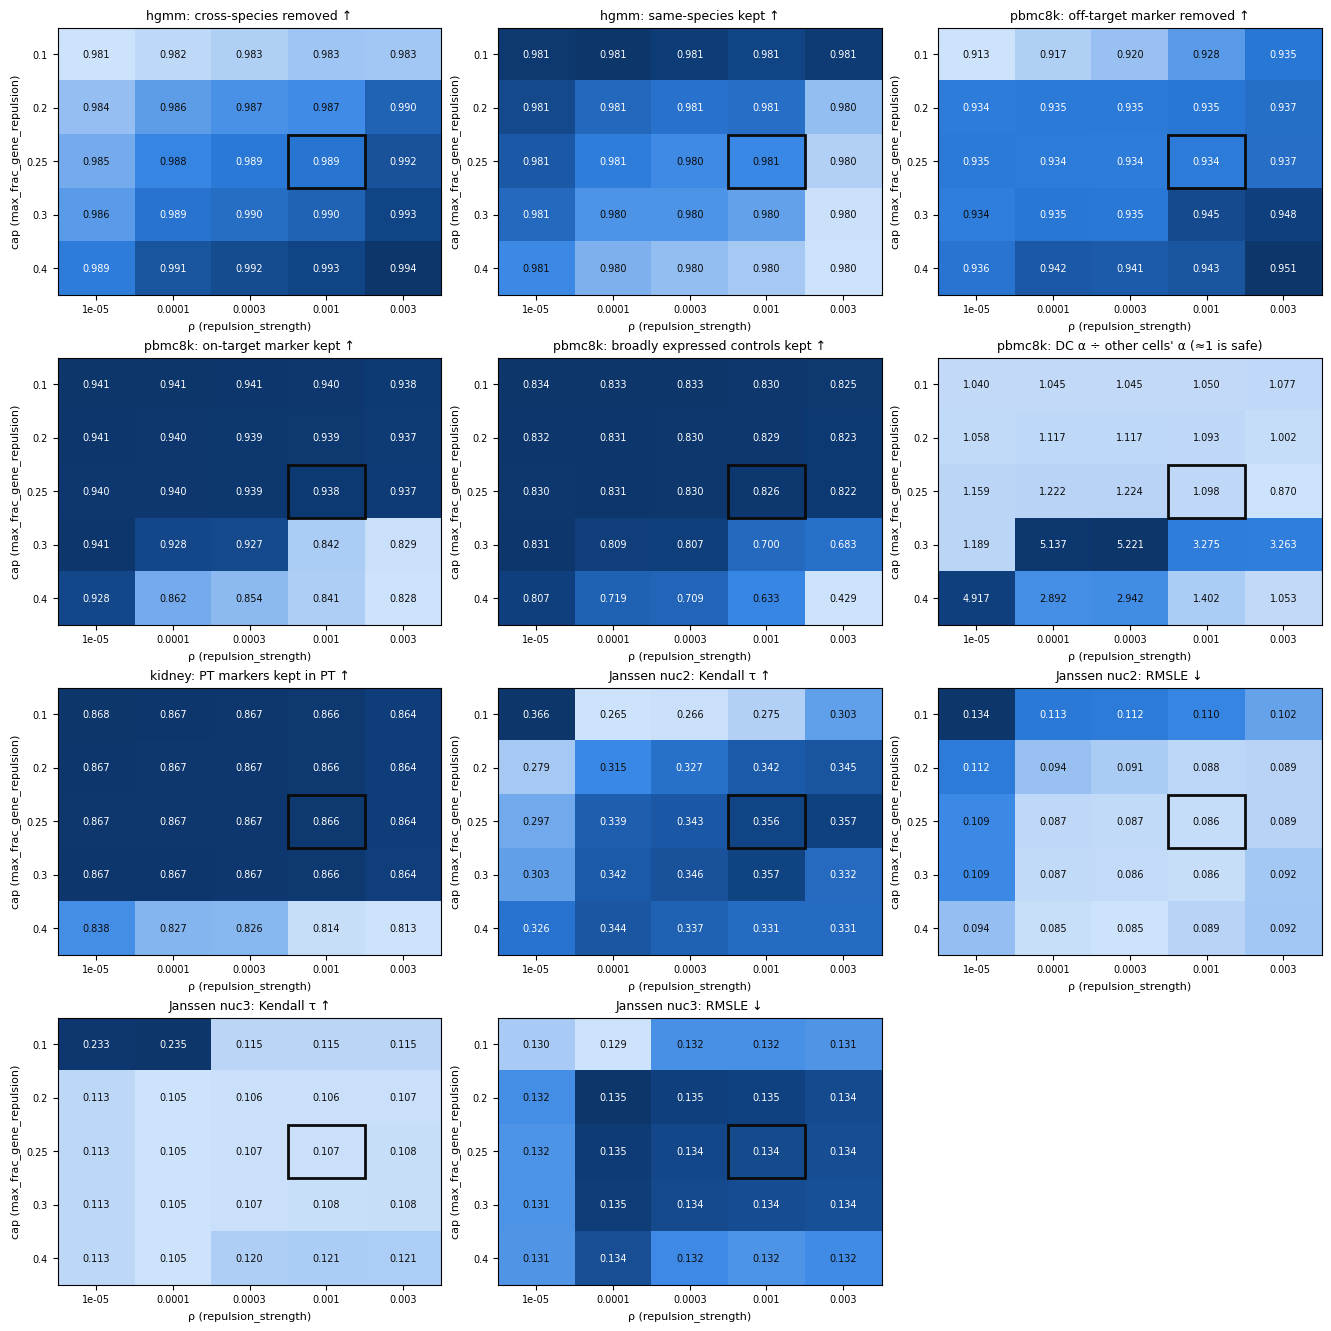

In [10]:
res = pd.read_csv(results_csv)
res = res[res["dataset"].isin(datasets)]
for c in ["rho", "kappa", "cap"]:
    res[c] = res[c].astype(float)

# Sequential blue ramp (light = low, dark = high); ordinal steps for rho in scatter plots
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
       "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ)

HEADLINE = [  # (dataset, column, title)
    ("hgmm_12k", "hgmm_noise_removed", "hgmm: cross-species removed ↑"),
    ("hgmm_12k", "hgmm_signal_kept", "hgmm: same-species kept ↑"),
    ("pbmc8k", "pbmc_offtarget_removed", "pbmc8k: off-target marker removed ↑"),
    ("pbmc8k", "pbmc_ontarget_kept", "pbmc8k: on-target marker kept ↑"),
    ("pbmc8k", "pbmc_controls_kept", "pbmc8k: broadly expressed controls kept ↑"),
    ("pbmc8k", "pbmc_DC_alpha_ratio", "pbmc8k: DC α ÷ other cells' α (≈1 is safe)"),
    ("kidney_nuclei_10k", "kidney_PT_markers_kept", "kidney: PT markers kept in PT ↑"),
    ("janssen_nuc2", "janssen_tau", "Janssen nuc2: Kendall τ ↑"),
    ("janssen_nuc2", "janssen_rmsle", "Janssen nuc2: RMSLE ↓"),
    ("janssen_nuc3", "janssen_tau", "Janssen nuc3: Kendall τ ↑"),
    ("janssen_nuc3", "janssen_rmsle", "Janssen nuc3: RMSLE ↓"),
]
HEADLINE = [h for h in HEADLINE if h[0] in set(res["dataset"]) and h[1] in res.columns]


def grid(ds, col, mode, rhos, caps):
    d = res[(res.dataset == ds) & (res["mode"] == mode) & np.isclose(res.kappa, default["kappa"])]
    g = d.pivot_table(index="cap", columns="rho", values=col)
    return g.reindex(index=caps, columns=rhos)


def heatmap(ax, g, title, fmt="{:.3f}"):
    vals = g.values.astype(float)
    finite = vals[np.isfinite(vals)]
    lo, hi = (finite.min(), finite.max()) if finite.size else (0, 1)
    ax.imshow(vals, cmap=SEQ_CMAP, vmin=lo, vmax=hi if hi > lo else lo + 1e-9, aspect="auto")
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isfinite(vals[i, j]):
                shade = (vals[i, j] - lo) / (hi - lo) if hi > lo else 0
                ax.text(j, i, fmt.format(vals[i, j]), ha="center", va="center", fontsize=7,
                        color="white" if shade > 0.55 else "#0b0b0b")
    rhos, caps = list(g.columns), list(g.index)
    if default["rho"] in rhos and default["cap"] in caps:
        di, dj = caps.index(default["cap"]), rhos.index(default["rho"])
        ax.add_patch(Rectangle((dj - 0.5, di - 0.5), 1, 1, fill=False, edgecolor="#0b0b0b", lw=2))
    ax.set_xticks(range(len(rhos)), [f"{r:g}" for r in rhos], fontsize=7)
    ax.set_yticks(range(len(caps)), [f"{c:g}" for c in caps], fontsize=7)
    ax.set_xlabel("ρ (repulsion_strength)", fontsize=8)
    ax.set_ylabel("cap (max_frac_gene_repulsion)", fontsize=8)
    ax.set_title(title, fontsize=9)


def save(fig, name):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(out_dir, f"{name}.{ext}"), dpi=300, bbox_inches="tight")


ncol = 3
nrow = int(np.ceil(len(HEADLINE) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.4 * ncol, 3.3 * nrow), constrained_layout=True, squeeze=False)
for ax, (ds, col, title) in zip(axes.flat, HEADLINE):
    heatmap(ax, grid(ds, col, "default", rho_grid, cap_grid), title)
for ax in axes.flat[len(HEADLINE):]:
    ax.axis("off")
save(fig, "heatmaps_default")
plt.show()

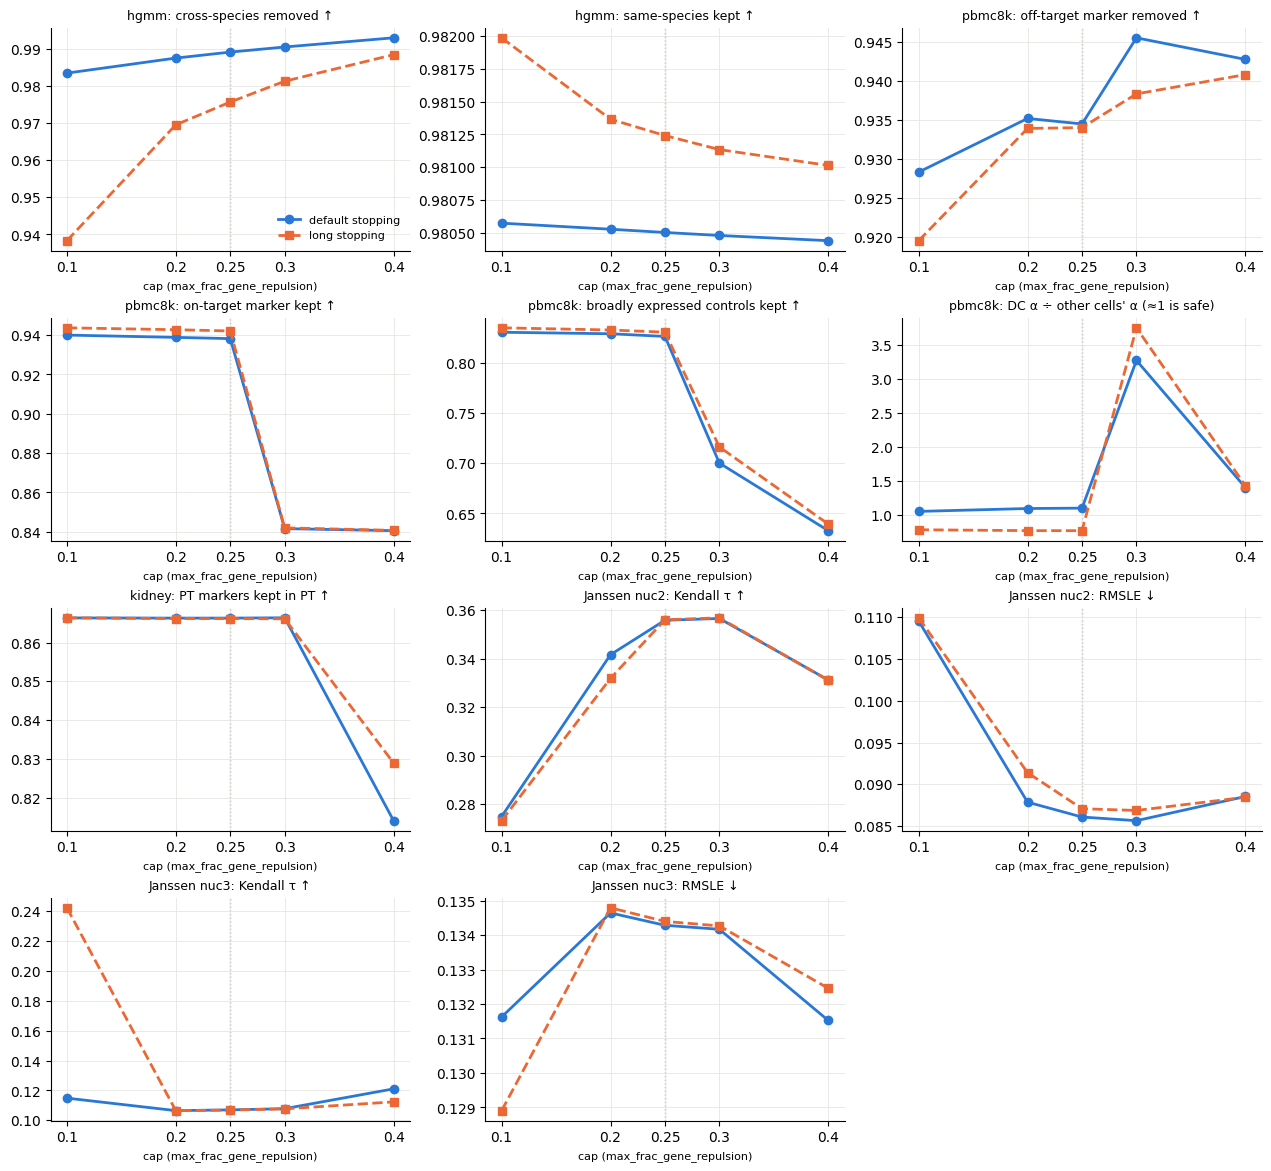

In [11]:
# convergence check: each metric along the cap column at the default rho, both stopping modes
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 2.9 * nrow), constrained_layout=True, squeeze=False)
col_rows = res[np.isclose(res.rho, default["rho"]) & np.isclose(res.kappa, default["kappa"]) & res.cap.isin(long_cap)]
for ax, (ds, col, title) in zip(axes.flat, HEADLINE):
    for mode, color, style in [("default", "#2a78d6", "-o"), ("long", "#eb6834", "--s")]:
        d = col_rows[(col_rows.dataset == ds) & (col_rows["mode"] == mode)].sort_values("cap")
        ax.plot(d.cap, d[col], style, color=color, lw=2, markersize=6, label=f"{mode} stopping")
    ax.axvline(default["cap"], color="#8c8b86", lw=1, ls=":", zorder=0)
    ax.set_xticks(long_cap, [f"{c:g}" for c in long_cap])
    ax.set_xlabel("cap (max_frac_gene_repulsion)", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(color="#e6e5e1", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[len(HEADLINE):]:
    ax.axis("off")
axes.flat[0].legend(frameon=False, fontsize=8)
save(fig, "convergence_check")
plt.show()

### β prior strength

κ swept at the default ρ and cap, default stopping. κ = 0 is the maximum-likelihood β, and larger κ
holds β̂ closer to 0.01.

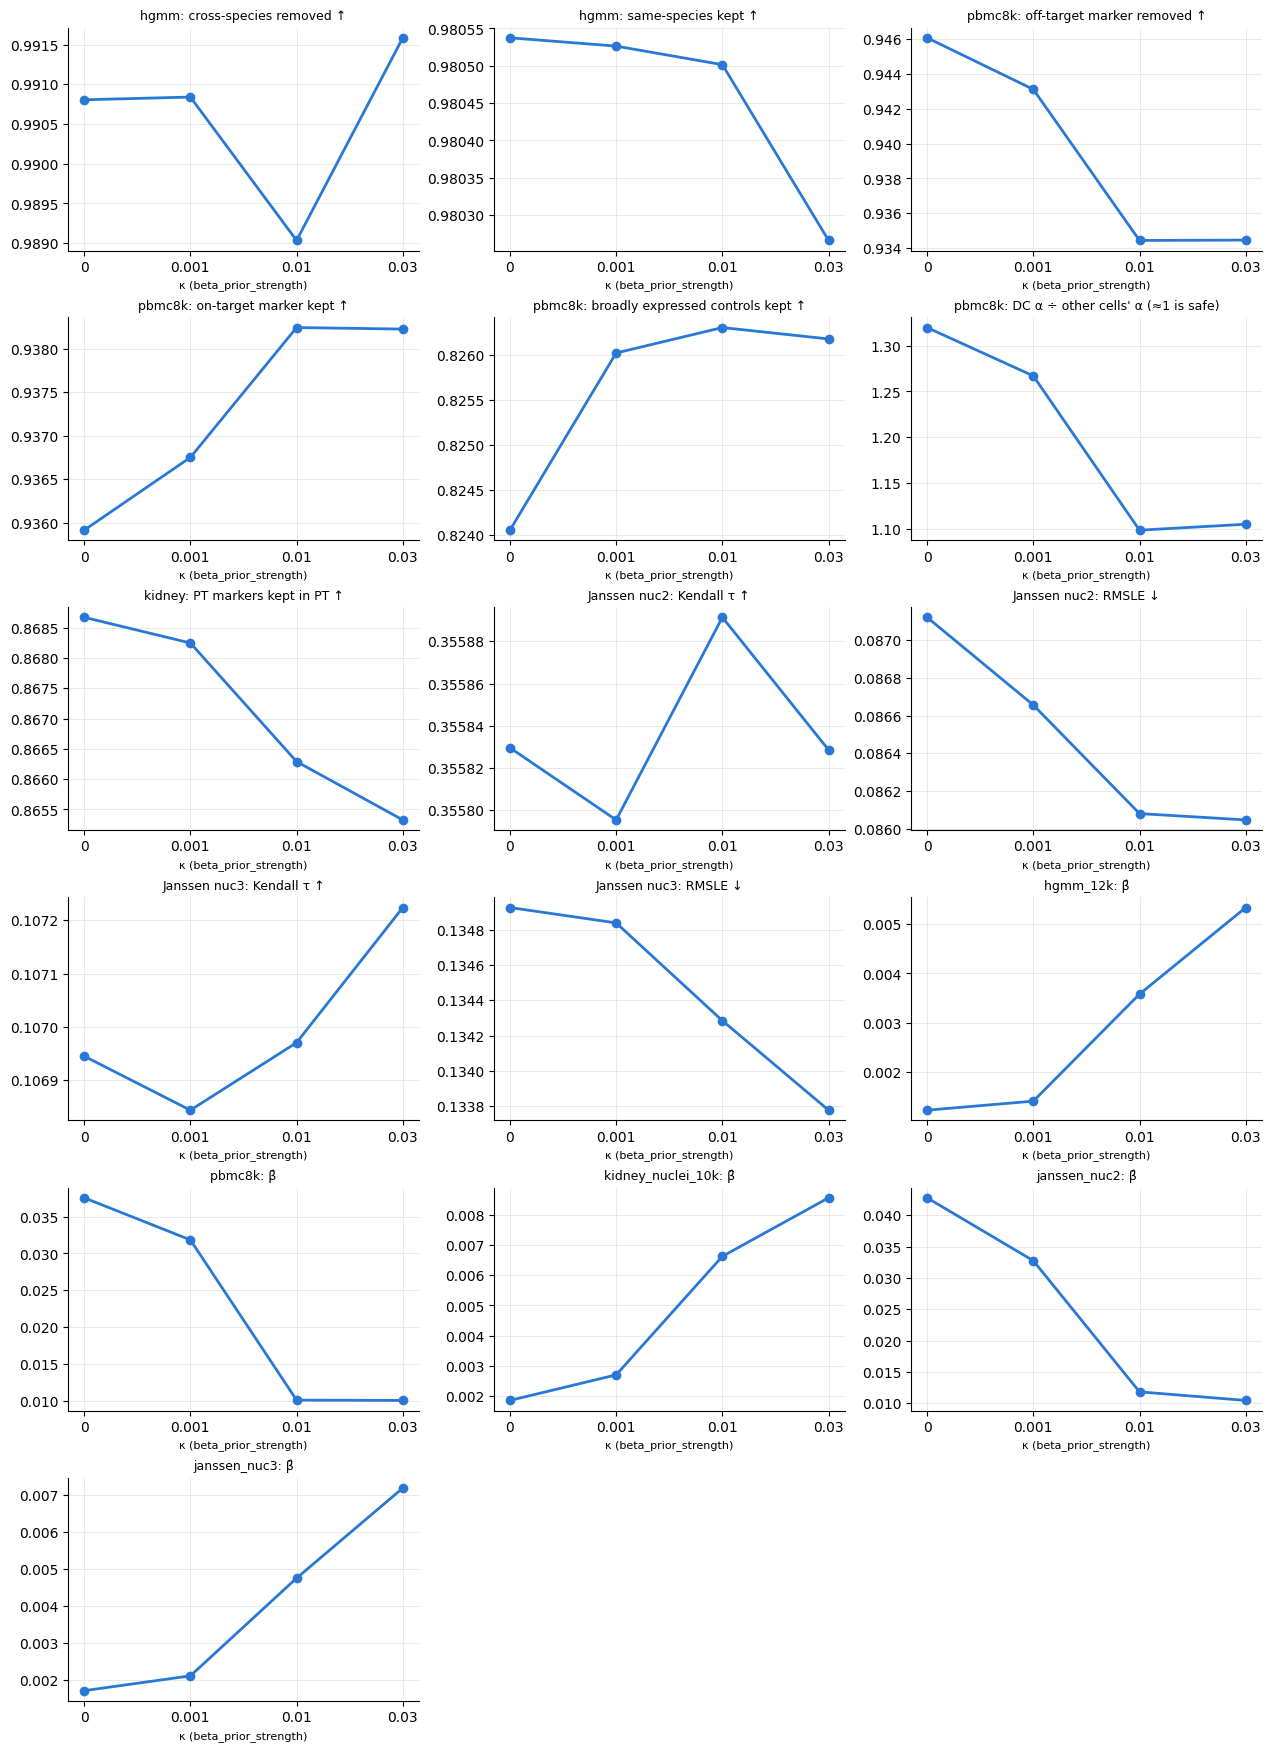

In [12]:
k_rows = res[np.isclose(res.rho, default["rho"]) & np.isclose(res.cap, default["cap"]) & res.kappa.isin(kappa_grid)]
panels = HEADLINE + [(ds, "beta_hat", f"{ds}: β̂") for ds in datasets if ds in set(res["dataset"])]
ncol = 3
fig, axes = plt.subplots(int(np.ceil(len(panels) / ncol)), ncol, figsize=(4.2 * ncol, 2.9 * np.ceil(len(panels) / ncol)),
                         constrained_layout=True, squeeze=False)
xpos = {k: i for i, k in enumerate(kappa_grid)}
for ax, (ds, col, title) in zip(axes.flat, panels):
    d = k_rows[(k_rows.dataset == ds) & (k_rows["mode"] == "default")].sort_values("kappa")
    ax.plot([xpos[k] for k in d.kappa], d[col], "-o", color="#2a78d6", lw=2, markersize=6)
    ax.set_xticks(range(len(kappa_grid)), [f"{k:g}" for k in kappa_grid])
    ax.set_xlabel("κ (beta_prior_strength)", fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(color="#e6e5e1", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes.flat[len(panels):]:
    ax.axis("off")
save(fig, "kappa_sweep")
plt.show()

### Summary table

Every setting and metric, with the default setting first. The table is descriptive: use it with
the plots above to judge how much each dataset's results move across the grid.

In [13]:
metric_cols = [c for c in res.columns if c not in ("dataset", "rho", "kappa", "cap", "mode", "seconds")
               and not c.startswith("kidney_removed_")]
summary = res.copy()
summary["is_default"] = (np.isclose(summary.rho, default["rho"]) & np.isclose(summary.kappa, default["kappa"])
                         & np.isclose(summary.cap, default["cap"]))
summary = summary.sort_values(["dataset", "mode", "is_default", "rho", "cap", "kappa"],
                              ascending=[True, True, False, True, True, True])
summary.to_csv(os.path.join(out_dir, "summary.csv"), index=False)
with pd.option_context("display.max_rows", 500, "display.max_columns", 50, "display.width", 250):
    for ds in datasets:
        d = summary[summary.dataset == ds].dropna(axis=1, how="all")
        cols = ["rho", "kappa", "cap", "mode", "is_default"] + [c for c in metric_cols if c in d.columns]
        print(f"=== {ds} ===")
        display(d[cols].round(4))

=== hgmm_12k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,hgmm_noise_removed,hgmm_signal_kept
17,0.0010,0.010,0.25,default,True,0.0036,0.0336,0.1067,35,0.9890,0.9805
0,0.0000,0.010,0.10,default,False,0.0033,0.0336,0.1065,33,0.9813,0.9806
1,0.0000,0.010,0.20,default,False,0.0034,0.0335,0.1066,34,0.9838,0.9806
2,0.0000,0.010,0.25,default,False,0.0034,0.0336,0.1066,34,0.9852,0.9805
3,0.0000,0.010,0.30,default,False,0.0034,0.0336,0.1067,34,0.9864,0.9805
4,0.0000,0.010,0.40,default,False,0.0035,0.0337,0.1067,34,0.9885,0.9805
5,0.0001,0.010,0.10,default,False,0.0034,0.0335,0.1065,34,0.9820,0.9806
6,0.0001,0.010,0.20,default,False,0.0034,0.0336,0.1067,34,0.9863,0.9805
7,0.0001,0.010,0.25,default,False,0.0035,0.0337,0.1067,34,0.9878,0.9805
8,0.0001,0.010,0.30,default,False,0.0035,0.0337,0.1067,34,0.9891,0.9805


=== pbmc8k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,pbmc_offtarget_removed,pbmc_ontarget_kept,pbmc_controls_kept,pbmc_DC_median_alpha,pbmc_DC_alpha_ratio
50,0.0010,0.010,0.25,default,True,0.0101,0.0695,0.1450,721,0.9344,0.9382,0.8263,0.0763,1.0983
33,0.0000,0.010,0.10,default,False,0.0107,0.0617,0.1384,362,0.9132,0.9414,0.8338,0.0640,1.0402
34,0.0000,0.010,0.20,default,False,0.0109,0.0632,0.1398,375,0.9342,0.9408,0.8322,0.0668,1.0582
35,0.0000,0.010,0.25,default,False,0.0116,0.0644,0.1417,372,0.9346,0.9399,0.8302,0.0744,1.1594
36,0.0000,0.010,0.30,default,False,0.0107,0.0648,0.1409,481,0.9338,0.9407,0.8310,0.0768,1.1893
37,0.0000,0.010,0.40,default,False,0.0121,0.0701,0.1580,446,0.9359,0.9278,0.8067,0.3369,4.9168
38,0.0001,0.010,0.10,default,False,0.0108,0.0621,0.1389,377,0.9173,0.9411,0.8332,0.0649,1.0450
39,0.0001,0.010,0.20,default,False,0.0119,0.0633,0.1409,415,0.9346,0.9398,0.8311,0.0705,1.1170
40,0.0001,0.010,0.25,default,False,0.0125,0.0630,0.1410,491,0.9345,0.9397,0.8310,0.0766,1.2218
41,0.0001,0.010,0.30,default,False,0.0112,0.0689,0.1565,572,0.9352,0.9276,0.8087,0.3447,5.1367


=== kidney_nuclei_10k ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,kidney_PT_markers_kept,kidney_PT_markers_removed_elsewhere
83,0.0010,0.010,0.25,default,True,0.0066,0.1037,0.1785,360,0.8663,0.2643
66,0.0000,0.010,0.10,default,False,0.0067,0.1005,0.1762,270,0.8675,0.2553
67,0.0000,0.010,0.20,default,False,0.0067,0.1011,0.1767,276,0.8671,0.2558
68,0.0000,0.010,0.25,default,False,0.0067,0.1010,0.1767,300,0.8671,0.2548
69,0.0000,0.010,0.30,default,False,0.0065,0.1018,0.1770,280,0.8672,0.2593
70,0.0000,0.010,0.40,default,False,0.0059,0.1437,0.2107,292,0.8382,0.2632
71,0.0001,0.010,0.10,default,False,0.0067,0.1010,0.1766,276,0.8673,0.2559
72,0.0001,0.010,0.20,default,False,0.0068,0.1012,0.1768,311,0.8670,0.2553
73,0.0001,0.010,0.25,default,False,0.0066,0.1019,0.1772,298,0.8670,0.2596
74,0.0001,0.010,0.30,default,False,0.0061,0.1026,0.1773,310,0.8672,0.2617


=== janssen_nuc2 ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,janssen_n,janssen_tau,janssen_rmsle,janssen_median_estimate,janssen_median_truth,janssen_pt_noise_removed,janssen_pt_signal_kept,janssen_constitutive_kept
116,0.0010,0.010,0.25,default,True,0.0118,0.4231,0.4080,572,1514.0,0.3559,0.0861,0.3665,0.3312,0.8576,0.5637,0.6235
99,0.0000,0.010,0.10,default,False,0.0083,0.2393,0.2400,843,1514.0,0.3659,0.1339,0.2149,0.3312,0.5975,0.7486,0.7767
100,0.0000,0.010,0.20,default,False,0.0088,0.2923,0.2864,1220,1514.0,0.2787,0.1124,0.2993,0.3312,0.5979,0.6852,0.7377
101,0.0000,0.010,0.25,default,False,0.0093,0.3409,0.3284,505,1514.0,0.2969,0.1088,0.3033,0.3312,0.6837,0.6384,0.6985
102,0.0000,0.010,0.30,default,False,0.0093,0.3433,0.3301,702,1514.0,0.3026,0.1087,0.3048,0.3312,0.6933,0.6378,0.6964
103,0.0000,0.010,0.40,default,False,0.0096,0.3460,0.3362,518,1514.0,0.3263,0.0944,0.3102,0.3312,0.7149,0.6293,0.6888
104,0.0001,0.010,0.10,default,False,0.0088,0.2981,0.2878,1198,1514.0,0.2649,0.1128,0.3098,0.3312,0.6007,0.7011,0.7370
105,0.0001,0.010,0.20,default,False,0.0099,0.3890,0.3706,809,1514.0,0.3149,0.0937,0.3341,0.3312,0.7232,0.5946,0.6663
106,0.0001,0.010,0.25,default,False,0.0106,0.3935,0.3801,413,1514.0,0.3390,0.0872,0.3367,0.3312,0.7993,0.5863,0.6547
107,0.0001,0.010,0.30,default,False,0.0105,0.3938,0.3804,453,1514.0,0.3417,0.0868,0.3378,0.3312,0.8007,0.5862,0.6543


=== janssen_nuc3 ===


,rho,kappa,cap,mode,is_default,beta_hat,median_alpha,removed,iterations,janssen_n,janssen_tau,janssen_rmsle,janssen_median_estimate,janssen_median_truth,janssen_pt_noise_removed,janssen_pt_signal_kept,janssen_constitutive_kept
149,0.0010,0.010,0.25,default,True,0.0048,0.1499,0.2048,270,398.0,0.1070,0.1343,0.1243,0.1795,0.7494,0.8460,0.8538
132,0.0000,0.010,0.10,default,False,0.0051,0.1357,0.1730,367,398.0,0.2331,0.1295,0.0895,0.1795,0.6359,0.8694,0.8832
133,0.0000,0.010,0.20,default,False,0.0050,0.1404,0.1807,368,398.0,0.1132,0.1317,0.1146,0.1795,0.6953,0.8657,0.8757
134,0.0000,0.010,0.25,default,False,0.0050,0.1405,0.1810,369,398.0,0.1132,0.1315,0.1148,0.1795,0.6954,0.8654,0.8755
135,0.0000,0.010,0.30,default,False,0.0051,0.1409,0.1811,370,398.0,0.1132,0.1315,0.1148,0.1795,0.6956,0.8624,0.8754
136,0.0000,0.010,0.40,default,False,0.0051,0.1409,0.1812,373,398.0,0.1134,0.1315,0.1148,0.1795,0.6958,0.8623,0.8753
137,0.0001,0.010,0.10,default,False,0.0051,0.1359,0.1732,460,398.0,0.2350,0.1286,0.0923,0.1795,0.6449,0.8695,0.8832
138,0.0001,0.010,0.20,default,False,0.0050,0.1412,0.1822,408,398.0,0.1053,0.1352,0.1182,0.1795,0.7080,0.8649,0.8743
139,0.0001,0.010,0.25,default,False,0.0051,0.1421,0.1832,416,398.0,0.1054,0.1349,0.1186,0.1795,0.7114,0.8616,0.8738
140,0.0001,0.010,0.30,default,False,0.0051,0.1423,0.1834,427,398.0,0.1054,0.1349,0.1187,0.1795,0.7118,0.8613,0.8736
